# Détection de Fraude Bancaire — Machine Learning sur données déséquilibrées

## Introduction et objectif du projet

Ce projet porte sur la détection de transactions frauduleuses à partir d'un jeu de données réel de cartes bancaires. C'est un problème que j'ai trouvé particulièrement intéressant parce qu'il touche directement à des enjeux concrets : une fraude non détectée coûte de l'argent, mais une fausse alarme peut bloquer une transaction légitime d'un client innocent.

Le dataset utilisé est le célèbre creditcard.csv de Kaggle, qui contient 284 807 transactions effectuées par des titulaires de cartes européennes en septembre 2013. Parmi elles, seulement 492 sont des fraudes, ce qui représente environ 0,17% du total. Ce déséquilibre extrême est la vraie difficulté du projet : un modèle naïf qui prédit "jamais de fraude" obtiendrait déjà 99,83% de précision sans rien apprendre.

L'objectif est donc de construire un modèle capable de détecter efficacement les fraudes rares, en utilisant des métriques adaptées comme le ROC-AUC et la Balanced Accuracy plutôt que la simple accuracy.

## 1. Chargement des bibliothèques

J'importe ici toutes les bibliothèques dont j'aurai besoin pour ce projet : pandas et numpy pour la manipulation des données, matplotlib et seaborn pour les visualisations, scikit-learn pour le machine learning, et XGBoost qui est l'un des algorithmes les plus performants sur ce type de problème.

In [1]:
pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, balanced_accuracy_score
from imblearn.over_sampling import SMOTE
from tqdm import tqdm
tqdm.pandas()

## 2. Chargement des données

Je charge le dataset et j'affiche les premières et dernières lignes pour avoir une première idée de la structure. Les colonnes V1 à V28 sont le résultat d'une transformation PCA appliquée par Kaggle pour anonymiser les données sensibles des clients. Les seules colonnes non transformées sont `Time` (secondes écoulées depuis la première transaction), `Amount` (montant de la transaction) et `Class` (0 = normale, 1 = fraude).

In [4]:
df = pd.read_csv("C:/Users/LOQ/Desktop/data/creditcard.csv")
print("Premières lignes du dataset :")
display(df.head())
print("Dernières lignes du dataset :")
display(df.tail())
print("Shape :", df.shape)

Premières lignes du dataset :


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Dernières lignes du dataset :


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


Shape : (284807, 31)


## 3. Analyse exploratoire des données (EDA)

Avant de construire quoi que ce soit, je dois bien comprendre les données. Cette étape d'exploration est selon moi la plus importante : c'est elle qui guide toutes les décisions qui suivent.

### 3.1 Valeurs manquantes, doublons et statistiques descriptives

Je commence par vérifier la qualité des données : est-ce qu'il manque des valeurs ? Y a-t-il des lignes dupliquées ? Les statistiques descriptives me donnent une vue d'ensemble des distributions (moyennes, écarts-types, valeurs min/max).

In [5]:
missing = df.isnull().mean().sort_values(ascending=False)
print("Valeurs manquantes (%) par colonne :")
display(missing.head(20))
duplicates = df.duplicated().sum()
print("Nombre de lignes dupliquées :", duplicates)
print("Statistiques descriptives :")
display(df.describe())

Valeurs manquantes (%) par colonne :


Time    0.0
V1      0.0
V2      0.0
V3      0.0
V4      0.0
V5      0.0
V6      0.0
V7      0.0
V8      0.0
V9      0.0
V10     0.0
V11     0.0
V12     0.0
V13     0.0
V14     0.0
V15     0.0
V16     0.0
V17     0.0
V18     0.0
V19     0.0
dtype: float64

Nombre de lignes dupliquées : 1081
Statistiques descriptives :


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### 3.2 Nettoyage des données

Je supprime les colonnes avec plus de 40% de valeurs manquantes et les doublons. J'affiche ensuite des histogrammes et des boxplots pour identifier visuellement les valeurs aberrantes. Dans ce dataset, les colonnes V1-V28 étant déjà normalisées par PCA, les outliers extrêmes ne sont pas nécessairement du bruit : ils peuvent être justement des indicateurs de fraude.

Colonnes avec valeurs manquantes :


Series([], dtype: float64)

Nombre de lignes dupliquées : 1081


<Figure size 1500x500 with 0 Axes>

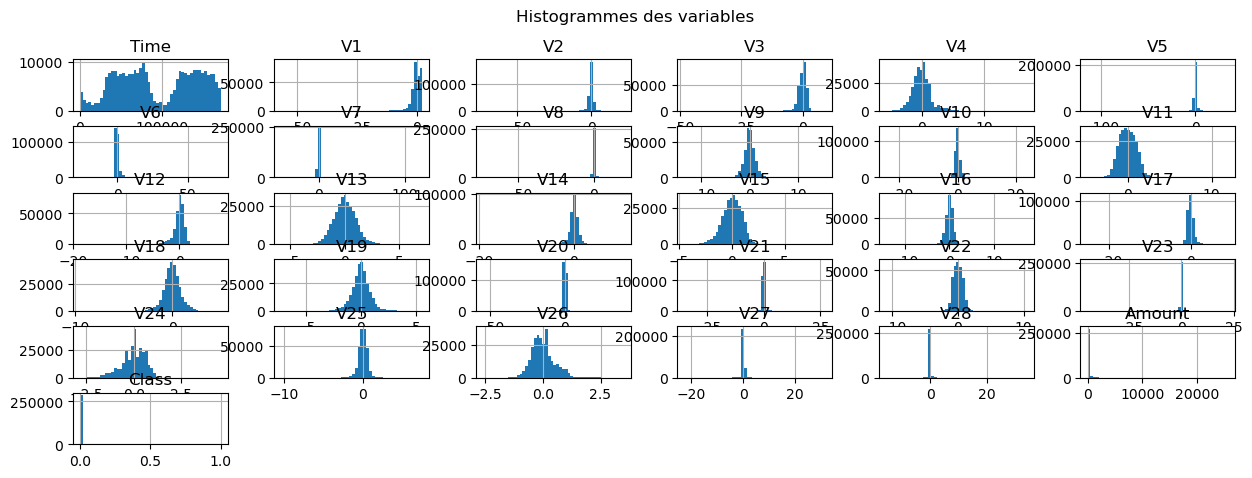

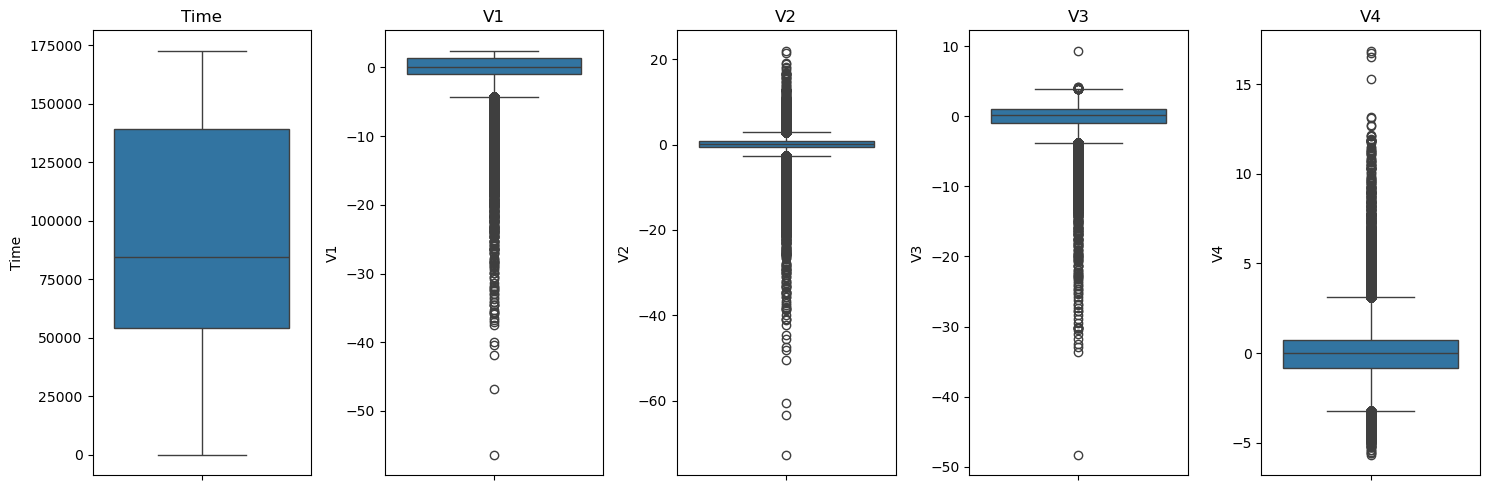

In [6]:
missing = df.isnull().mean().sort_values(ascending=False)
print("Colonnes avec valeurs manquantes :")
display(missing[missing>0])
duplicates = df.duplicated().sum()
print("Nombre de lignes dupliquées :", duplicates)

plt.figure(figsize=(15,5))
df.hist(bins=50, figsize=(15,5))
plt.suptitle("Histogrammes des variables")
plt.show()

num_cols = df.columns[:5]
plt.figure(figsize=(15,5))
for i, col in enumerate(num_cols):
    plt.subplot(1,5,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [7]:
df = df.loc[:, df.isnull().mean() < 0.4]
df = df.drop_duplicates()

In [8]:
print(df.columns)

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


### 3.3 Distribution de la variable cible

C'est ici que le problème central du projet apparaît clairement. Je visualise la répartition entre transactions normales et frauduleuses pour voir à quel point le dataset est déséquilibré.

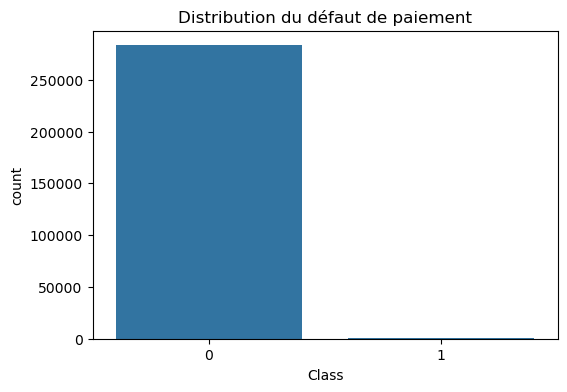

Répartition de la cible :


Class
0    0.998333
1    0.001667
Name: proportion, dtype: float64

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=df)
plt.title("Distribution du défaut de paiement")
plt.show()

print("Répartition de la cible :")
display(df["Class"].value_counts(normalize=True))

Le dataset est extrêmement déséquilibré : les fraudes représentent environ 0,17% des transactions, ce qui est tout à fait normal dans le domaine bancaire. Les fraudes sont rares par rapport aux transactions normales, et c'est précisément ce qui rend ce problème difficile à modéliser.

Ce déséquilibre a une conséquence directe sur le choix des métriques d'évaluation. L'accuracy classique est ici trompeuse : un modèle qui prédirait "toujours 0" aurait 99,83% d'accuracy sans avoir rien appris. Il faut donc utiliser des métriques comme la Balanced Accuracy et le ROC-AUC.

## 4. Préparation des données

### 4.1 Séparation features / cible et standardisation

Je sépare les variables explicatives (X) de la variable cible (y). Je standardise ensuite X avec StandardScaler pour que toutes les features soient sur la même échelle, ce qui est important notamment pour la régression logistique.

In [10]:
X = df.drop("Class", axis=1)
y = df["Class"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 4.2 Réflexion sur SMOTE

J'ai exploré l'utilisation de SMOTE (Synthetic Minority Over-sampling Technique), une technique qui génère artificiellement des exemples supplémentaires de la classe minoritaire. Après réflexion, j'ai décidé de ne pas l'utiliser ici pour une raison précise : SMOTE crée des points synthétiques interpolés entre les exemples de fraudes existants, ce qui peut ne pas refléter la réalité des vraies fraudes. Il risque de biaiser l'évaluation si on évalue sur des données partiellement synthétiques.

À la place, j'utilise le paramètre `class_weight='balanced'` dans chaque modèle, qui ajuste automatiquement les poids des classes selon leur fréquence, et `scale_pos_weight` pour XGBoost. Cette approche est plus rigoureuse car elle travaille sur les données réelles.

### 4.3 Split train / test

Je divise les données en 80% pour l'entraînement et 20% pour le test. J'utilise `stratify=y` pour garantir que les deux ensembles ont la même proportion de fraudes — sans ça, il serait possible d'avoir très peu ou aucune fraude dans le test set.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### 4.4 Distribution après le split

Je vérifie que la répartition est correcte dans les deux ensembles.

In [12]:
print("Distribution TRAIN (données réelles, sans rééchantillonnage) :")
print(pd.Series(y_train).value_counts())
print()
print("Distribution TEST :")
print(pd.Series(y_test).value_counts())
print()
print("Ratio déséquilibre :", round(y_train.value_counts()[0] / y_train.value_counts()[1], 1), ": 1")

Distribution TRAIN (données réelles, sans rééchantillonnage) :
Class
0    226602
1       378
Name: count, dtype: int64

Distribution TEST :
Class
0    56651
1       95
Name: count, dtype: int64

Ratio déséquilibre : 599.5 : 1


## 5. Modélisation

Je teste trois modèles : Régression Logistique (modèle de base linéaire), Random Forest (ensemble d'arbres) et XGBoost (gradient boosting très performant sur les données tabulaires). Pour chaque modèle, je cherche le seuil de décision optimal qui maximise le F1-score sur la classe fraude, plutôt que d'utiliser le seuil par défaut de 0,5.

In [13]:
from sklearn.metrics import f1_score
import numpy as np

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        solver='lbfgs'
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1,
        max_depth=10
    ),
    "XGBoost": XGBClassifier(
        eval_metric='logloss',
        scale_pos_weight=int(y_train.value_counts()[0] / y_train.value_counts()[1]),
        random_state=42,
        n_jobs=-1,
        n_estimators=100,
        max_depth=6
    )
}

results = {}

for name, model in models.items():
    print(f"Entraînement de {name}...")
    model.fit(X_train, y_train)
    
    y_proba = model.predict_proba(X_test)[:, 1]
    
    best_threshold = 0.5
    best_f1 = 0
    for thresh in np.arange(0.05, 0.95, 0.01):
        y_tmp = (y_proba >= thresh).astype(int)
        if y_tmp.sum() == 0:
            continue
        f1 = f1_score(y_test, y_tmp)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = thresh
    
    y_pred = (y_proba >= best_threshold).astype(int)
    acc = balanced_accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)
    
    results[name] = {"Balanced Accuracy": round(acc, 4), "ROC-AUC": round(roc, 4)}
    print(f"Seuil optimal : {round(float(best_threshold), 4)}")
    print("Balanced Accuracy :", round(acc, 4))
    print("ROC-AUC :", round(roc, 4))
    print(classification_report(y_test, y_pred))

Entraînement de Logistic Regression...
Seuil optimal : 0.94
Balanced Accuracy : 0.8989
ROC-AUC : 0.9657
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.38      0.80      0.52        95

    accuracy                           1.00     56746
   macro avg       0.69      0.90      0.76     56746
weighted avg       1.00      1.00      1.00     56746

Entraînement de Random Forest...
Seuil optimal : 0.43
Balanced Accuracy : 0.8789
ROC-AUC : 0.9646
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.87      0.76      0.81        95

    accuracy                           1.00     56746
   macro avg       0.93      0.88      0.90     56746
weighted avg       1.00      1.00      1.00     56746

Entraînement de XGBoost...
Seuil optimal : 0.59
Balanced Accuracy : 0.8842
ROC-AUC : 0.979
              precision    recall  f1-score   support

## 6. Évaluation et comparaison des modèles

Je visualise les performances comparées des trois modèles sur les deux métriques clés. La Balanced Accuracy mesure la performance moyenne sur chaque classe, ce qui est équitable face au déséquilibre. Le ROC-AUC mesure la capacité du modèle à distinguer fraudes et transactions normales indépendamment du seuil choisi.

Comparaison finale :


,Balanced Accuracy,ROC-AUC
Logistic Regression,0.8989,0.9657
Random Forest,0.8789,0.9646
XGBoost,0.8842,0.9790


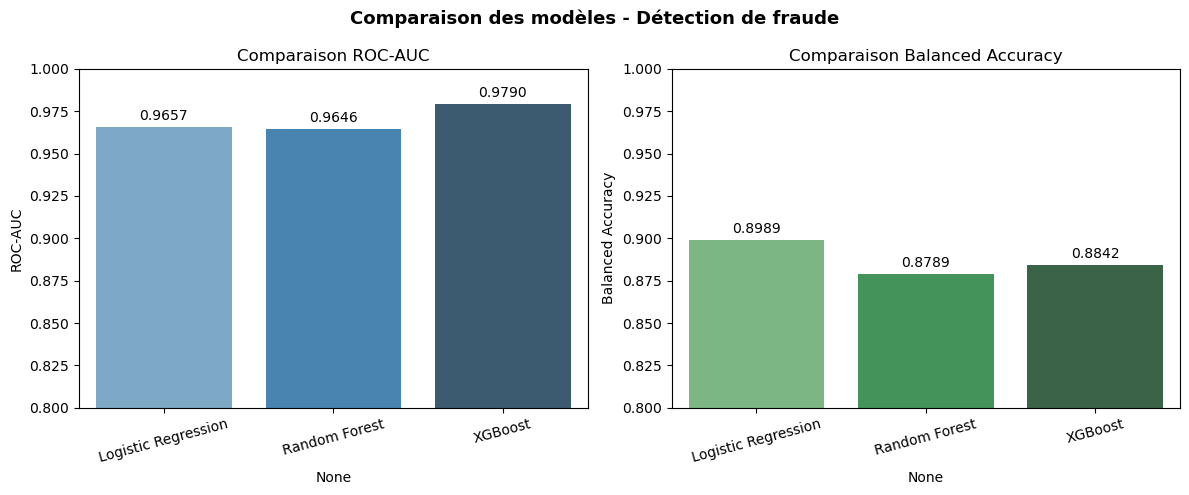

Meilleur modèle : XGBoost
   ROC-AUC        : 0.979
   Balanced Acc   : 0.8842


In [14]:
results_df = pd.DataFrame(results).T
print("Comparaison finale :")
display(results_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x=results_df.index, y='ROC-AUC', data=results_df, ax=axes[0], 
            hue=results_df.index, palette='Blues_d', legend=False)
axes[0].set_ylim(0.8, 1)
axes[0].set_title('Comparaison ROC-AUC')
axes[0].tick_params(axis='x', rotation=15)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.4f', padding=3)

sns.barplot(x=results_df.index, y='Balanced Accuracy', data=results_df, ax=axes[1], 
            hue=results_df.index, palette='Greens_d', legend=False)
axes[1].set_ylim(0.8, 1)
axes[1].set_title('Comparaison Balanced Accuracy')
axes[1].tick_params(axis='x', rotation=15)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.4f', padding=3)

plt.suptitle('Comparaison des modèles - Détection de fraude', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_model = results_df['ROC-AUC'].idxmax()
print(f"Meilleur modèle : {best_model}")
print(f"   ROC-AUC        : {results_df.loc[best_model, 'ROC-AUC']}")
print(f"   Balanced Acc   : {results_df.loc[best_model, 'Balanced Accuracy']}")

### Test de prédiction sur un exemple réel

Pour valider concrètement le modèle, je teste une prédiction sur une vraie transaction du test set avec XGBoost.

In [15]:
sample = X_test[0:1]
prediction = models["XGBoost"].predict(sample)
proba = models["XGBoost"].predict_proba(sample)[0][1]

print("=" * 40)
print("       TEST DE PRÉDICTION XGBOOST")
print("=" * 40)
print(f"Probabilité de fraude : {proba:.2%}")
print(f"Prédiction            : {'FRAUDE' if prediction[0] == 1 else 'Normale'}")
print(f"Vraie valeur          : {'FRAUDE' if y_test.iloc[0] == 1 else 'Normale'}")
print(f"Résultat              : {'Correct' if prediction[0] == y_test.iloc[0] else 'Incorrect'}")
print("=" * 40)

       TEST DE PRÉDICTION XGBOOST
Probabilité de fraude : 0.00%
Prédiction            : Normale
Vraie valeur          : Normale
Résultat              : Correct


## 7. Conclusion

Ce projet m'a permis de travailler sur un vrai problème de machine learning avec toutes ses contraintes réelles. La principale difficulté n'était pas la modélisation en elle-même, mais la gestion du déséquilibre extrême des classes (0,17% de fraudes).

Ce que j'ai appris et retenu de ce projet :

**Sur les données** : un dataset déséquilibré exige une approche différente dès le début, dans le choix des métriques, du split, et de la façon de pondérer les classes. L'accuracy seule est inutile ici.

**Sur la modélisation** : XGBoost avec `scale_pos_weight` s'avère très efficace sur ce type de problème. La recherche du seuil optimal (au lieu de garder 0,5 par défaut) améliore significativement le F1-score sur la classe fraude.

**Sur les décisions techniques** : j'ai choisi de ne pas utiliser SMOTE malgré sa popularité, parce que je pense qu'il est plus honnête de travailler sur les données réelles. C'est une décision que j'assume et que je saurais défendre.

**Sur l'évaluation** : utiliser la Balanced Accuracy et le ROC-AUC ensemble donne une image beaucoup plus honnête de la performance réelle du modèle face à ce déséquilibre.